# Detecção de Objetos com YOLOS (Hugging Face)

Este notebook utiliza o modelo `hustvl/yolos-small` para detectar e reconhecer objetos em imagens. As informações de classe e confiança são exibidas diretamente sobre as imagens.

In [1]:
import torch
from transformers import YolosImageProcessor, YolosForObjectDetection
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from collections import Counter

print(f"Torch version: {torch.__version__}")

Torch version: 2.10.0+cu128


## 1. Carregar o Modelo e o Processador

In [2]:
model_name = "hustvl/yolos-small"
print(f"📦 Carregando processador e modelo: {model_name}...")

image_processor = YolosImageProcessor.from_pretrained(model_name)
model = YolosForObjectDetection.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"✅ Modelo carregado no dispositivo: {device}")

📦 Carregando processador e modelo: hustvl/yolos-small...


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

✅ Modelo carregado no dispositivo: cpu


## 2. Função de Detecção e Visualização

In [3]:
def detect_objects(img_path, threshold=0.7, ax=None):
    """
    Realiza a detecção de objetos e desenha as informações identificadas.
    """
    try:
        image = Image.open(img_path).convert("RGB")
    except Exception as e:
        print(f"Erro ao abrir {img_path}: {e}")
        return []
    
    inputs = image_processor(images=image, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Post-processamento
    target_sizes = torch.tensor([image.size[::-1]]).to(device)
    results = image_processor.post_process_object_detection(outputs, threshold=threshold, target_sizes=target_sizes)[0]
    
    should_show = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))
        should_show = True
    
    ax.imshow(image)
    colors = plt.cm.hsv(np.linspace(0, 1, 100)).tolist()
    detections = []
    
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        label_idx = label.item()
        label_name = model.config.id2label.get(label_idx, f"ID {label_idx}")
        confidence = score.item()
        detections.append(label_name)
        
        xmin, ymin, xmax, ymax = [round(i, 2) for i in box.tolist()]
        color = colors[label_idx % 100]
        
        # Desenhar box e label com confiança
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color=color, linewidth=2.5))
        display_text = f"{label_name}: {confidence:.2f}"
        ax.text(xmin, ymin - 5 if ymin > 20 else ymin + 20, display_text, 
                fontsize=9, fontweight='bold', color='white', 
                bbox=dict(facecolor=color, alpha=0.8, edgecolor='none', pad=2))
    
    ax.set_title(f"{os.path.basename(img_path)} ({len(detections)} objetos)", fontsize=10)
    ax.axis("off")
    
    if should_show:
        plt.tight_layout()
        plt.show()
        
    return detections

## 3. Executando Detecção nas Imagens da Pasta

🚀 Processando 4 imagens em 'imagens'...


  0%|          | 0/4 [00:00<?, ?it/s]

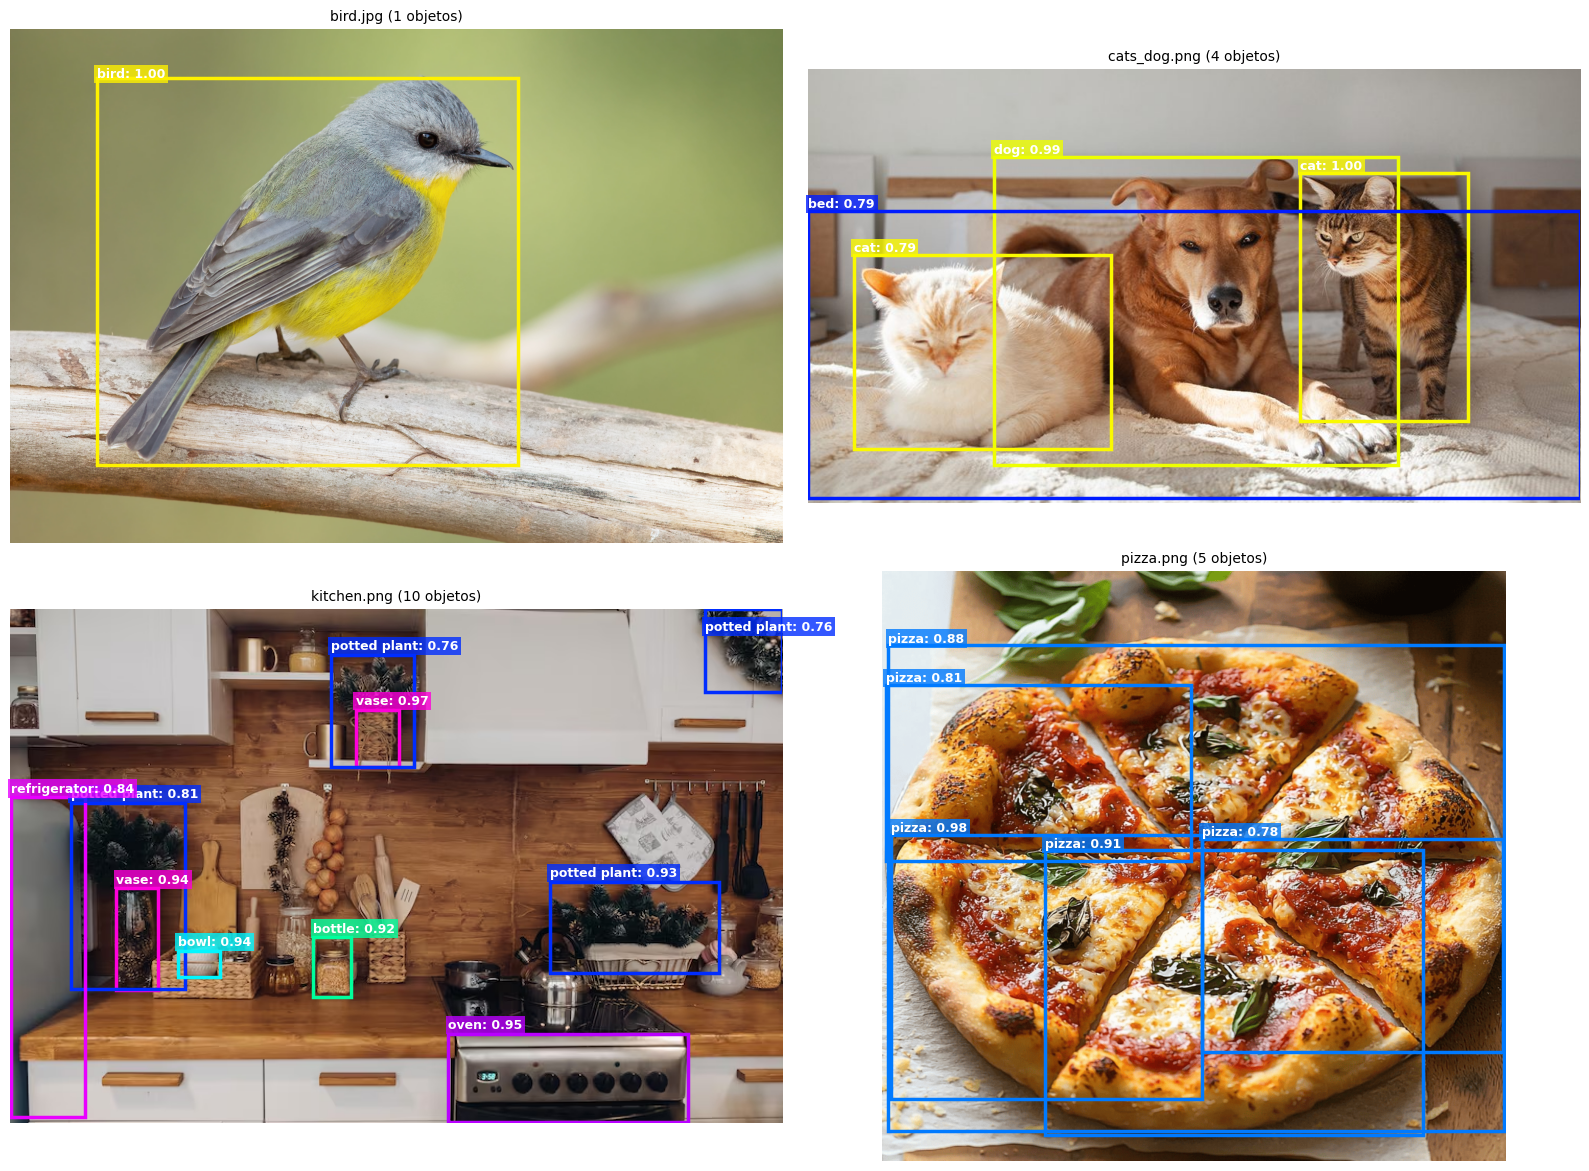


📊 =============================================
          RESUMO GLOBAL DA DETECÇÃO          
  • pizza                ->  5 ocorrências
  • potted plant         ->  4 ocorrências
  • cat                  ->  2 ocorrências
  • vase                 ->  2 ocorrências
  • bird                 ->  1 ocorrências
  • dog                  ->  1 ocorrências
  • bed                  ->  1 ocorrências
  • bottle               ->  1 ocorrências
  • oven                 ->  1 ocorrências
  • refrigerator         ->  1 ocorrências
  • bowl                 ->  1 ocorrências


In [4]:
img_dir = "imagens"
valid_extensions = (".png", ".jpg", ".jpeg")
threshold = 0.7

if os.path.exists(img_dir):
    images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(valid_extensions)])
    
    if not images:
        print(f"Nenhuma imagem encontrada em '{img_dir}'.")
    else:
        n_imgs = len(images)
        cols = 2
        rows = (n_imgs + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
        axes_flat = axes.flatten() if n_imgs > 1 else [axes]
        
        all_detections = []
        print(f"🚀 Processando {n_imgs} imagens em '{img_dir}'...")
        
        for i, img_name in enumerate(tqdm(images)):
            img_path = os.path.join(img_dir, img_name)
            detections = detect_objects(img_path, threshold=threshold, ax=axes_flat[i])
            all_detections.extend(detections)
        
        for j in range(i + 1, len(axes_flat)): axes_flat[j].axis('off')
            
        plt.tight_layout()
        plt.show()
        
        # Resumo Estatístico Consolidado
        print("\n📊 " + "="*45)
        print(f"{'RESUMO GLOBAL DA DETECÇÃO':^45}")
        print("="*48)
        counts = Counter(all_detections)
        if not counts:
            print("⚠️ Nenhum objeto detectado com o threshold atual.")
        else:
            for obj, count in counts.most_common():
                print(f"  • {obj:20} -> {count:2} ocorrências")
        print("="*48)
else:
    print(f"❌ Pasta '{img_dir}' não encontrada.")